In [32]:
import pandas as pd

df = pd.read_csv("../data/raw/train.csv", encoding='cp932')

print("=== shape ===")
print(df.shape)

print("\n=== dtypes ===")
print(df.dtypes)

print("\n=== head(10) ===")
print(df.head(10))

=== shape ===
(1322, 1559)

=== dtypes ===
sample number       int64
species number      int64
樹種                 object
含水率               float64
9993.76781        float64
                   ...   
4015.24982        float64
4011.39271        float64
4007.5356         float64
4003.6785         float64
3999.82139        float64
Length: 1559, dtype: object

=== head(10) ===
   sample number  species number    樹種         含水率  9993.76781  9989.9107  \
0              1               1  イチョウ  216.129032     0.41485    0.41465   
1              2               1  イチョウ  210.752688     0.42049    0.42040   
2              3               1  イチョウ  205.913979     0.41040    0.41045   
3              4               1  イチョウ  201.075269     0.40080    0.40061   
4              5               1  イチョウ  196.236559     0.38792    0.38814   
5              6               1  イチョウ  191.397850     0.37605    0.37619   
6              7               1  イチョウ  186.559140     0.36943    0.36942   
7        

In [33]:

# 各樹種ごとのレコード数
record_counts = df.groupby('樹種')['sample number'].count().reset_index()
record_counts.columns = ['樹種', 'レコード数']
record_counts = record_counts.sort_values('レコード数', ascending=False).reset_index(drop=True)
print(f"樹種数: {len(record_counts)}")
record_counts


樹種数: 13


,樹種,レコード数
0,トチ,183
1,ヒノキ,141
2,ベイスギ,112
3,ウォールナット,110
4,ナラ,107
5,スプルース,97
6,イチョウ,94
7,ベイマツ,93
8,クリ,91
9,チェリー,88


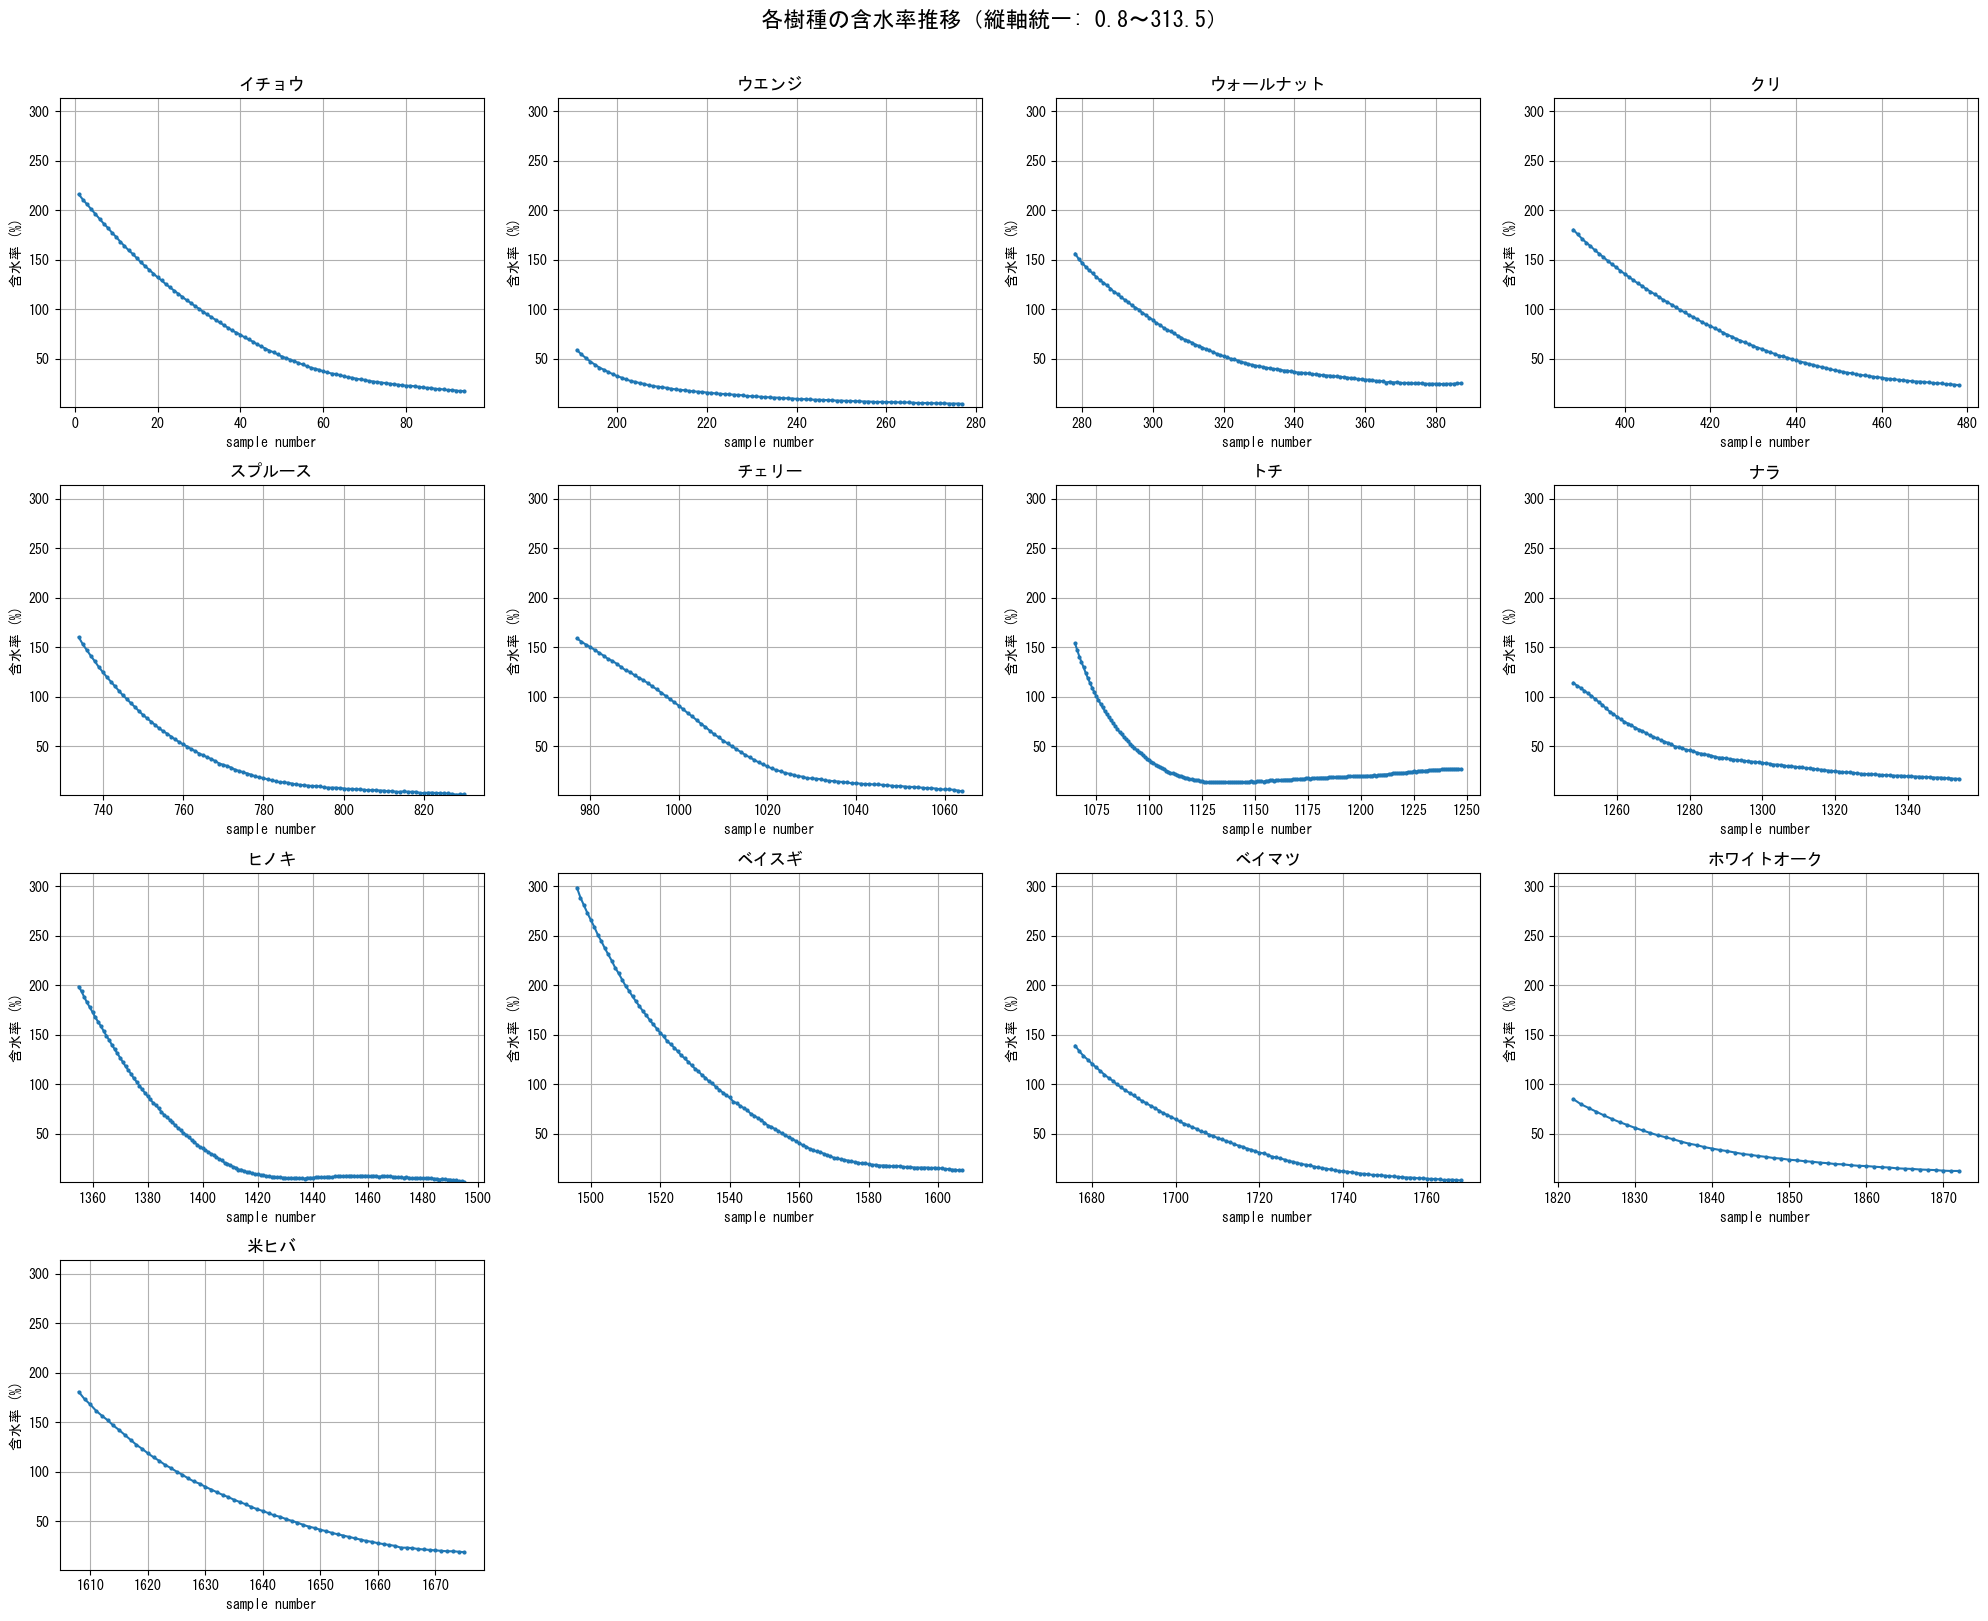

In [34]:

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'MS Gothic'  # 日本語フォント

# ===== パラメータ =====
ylim = None        # Noneで全樹種の範囲に自動統一。手動指定例: (0, 300)
# ====================

species_list = df['樹種'].unique()
n = len(species_list)
cols = 4
rows = (n + cols - 1) // cols

# ylim の決定
if ylim is None:
    y_min = df['含水率'].min()
    y_max = df['含水率'].max()
    ylim_actual = (y_min * 0.95, y_max * 1.05)
else:
    ylim_actual = ylim

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i, species in enumerate(sorted(species_list)):
    subset = df[df['樹種'] == species].sort_values('sample number')
    axes[i].plot(subset['sample number'], subset['含水率'], marker='o', markersize=2)
    axes[i].set_title(species)
    axes[i].set_xlabel('sample number')
    axes[i].set_ylabel('含水率 (%)')
    axes[i].set_ylim(ylim_actual)
    axes[i].grid(True)

# 余ったaxesを非表示
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'各樹種の含水率推移（縦軸統一: {ylim_actual[0]:.1f}〜{ylim_actual[1]:.1f}）', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


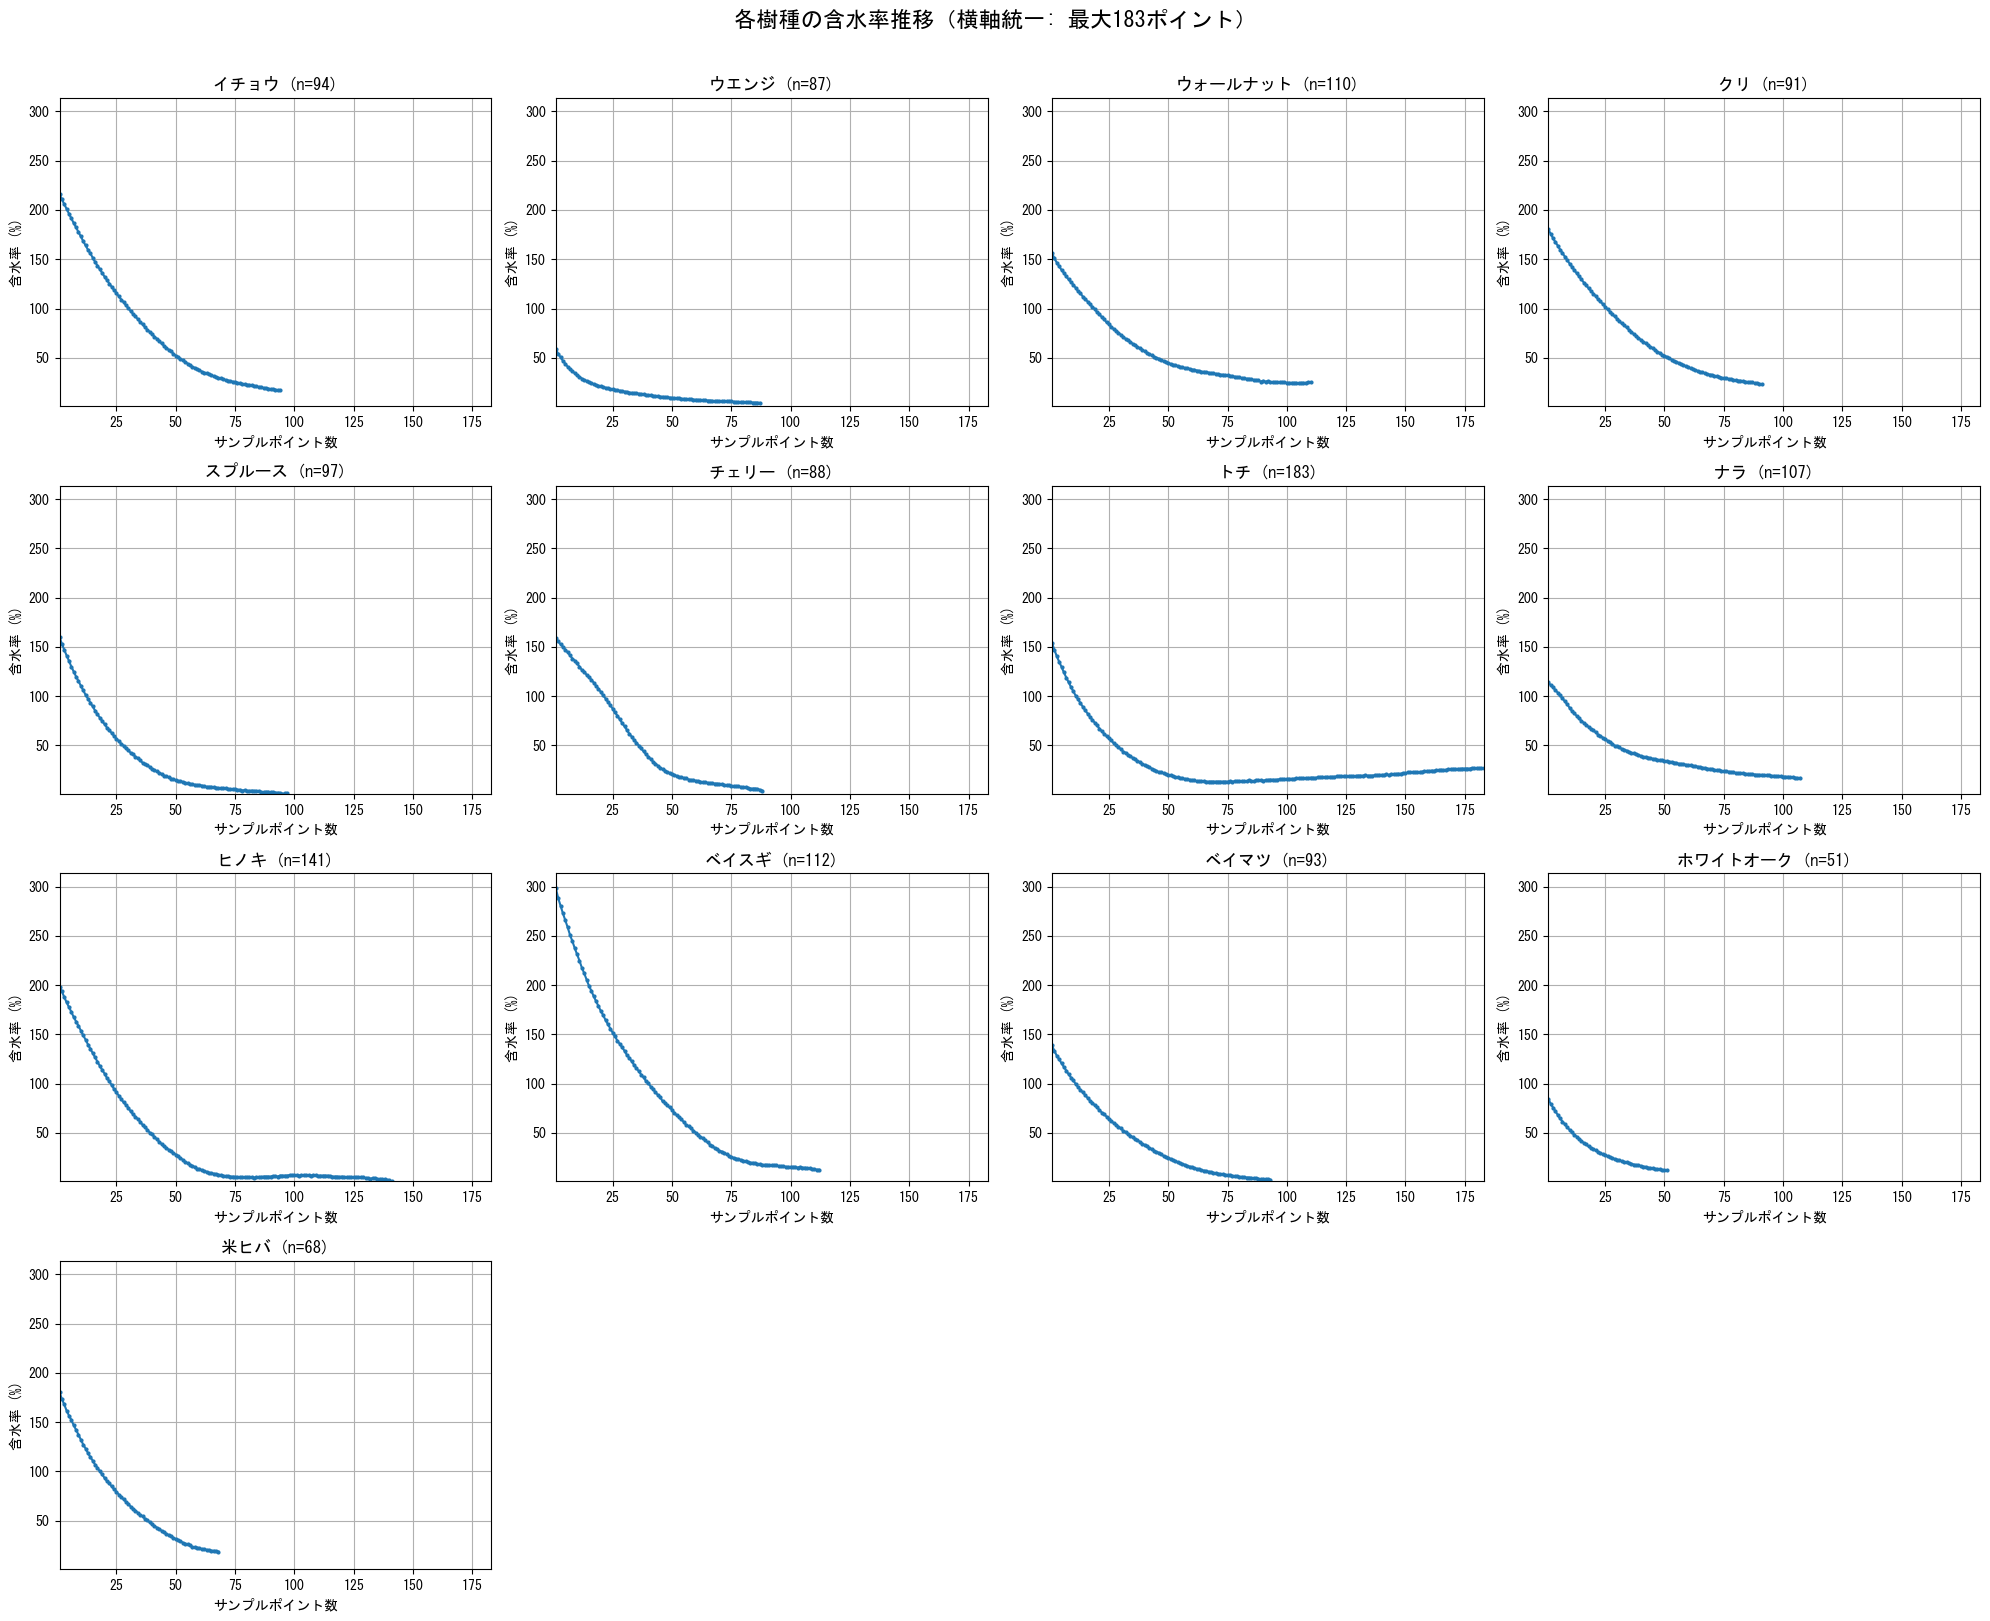

In [25]:

# 各樹種のサンプルポイント数の最大値を算出
max_points = df.groupby('樹種').size().max()

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

# ===== パラメータ =====
ylim = None        # Noneで全樹種の範囲に自動統一。手動指定例: (0, 300)
# ====================

# ylim の決定
if ylim is None:
    y_min = df['含水率'].min()
    y_max = df['含水率'].max()
    ylim_actual = (y_min * 0.95, y_max * 1.05)
else:
    ylim_actual = ylim


for i, species in enumerate(sorted(species_list)):
    subset = df[df['樹種'] == species].sort_values('sample number').reset_index(drop=True)
    x = subset.index + 1  # 1始まりのサンプルポイント数
    axes[i].plot(x, subset['含水率'], marker='o', markersize=2)
    axes[i].set_title(f"{species} (n={len(subset)})")
    axes[i].set_xlabel('サンプルポイント数')
    axes[i].set_ylabel('含水率 (%)')
    axes[i].set_xlim(1, max_points)
    axes[i].set_ylim(ylim_actual)
    axes[i].grid(True)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'各樹種の含水率推移（横軸統一: 最大{max_points}ポイント）', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


In [26]:

import numpy as np

# スペクトル列の取得
spectrum_cols = [c for c in df.columns if c not in ['sample number', 'species number', '樹種', '含水率']]
spectrum_cols_float = np.array([float(c) for c in spectrum_cols])

# 10cm⁻¹ごとのビンを作成（4000〜10000）
bins = np.arange(4000, 10010, 10)

# 各ビンに対応する列を特定
bin_col_map = {}
for i in range(len(bins) - 1):
    low, high = bins[i], bins[i + 1]
    mask = (spectrum_cols_float >= low) & (spectrum_cols_float < high)
    matched = [spectrum_cols[j] for j, m in enumerate(mask) if m]
    if matched:
        bin_col_map[f"{int(low)}-{int(high)}"] = matched

print(f"ビン数: {len(bin_col_map)}")

# 各サンプルごとにビンの平均値を算出
df_bin_mean = df[['sample number', 'species number', '樹種', '含水率']].copy()

for bin_label, cols in bin_col_map.items():
    df_bin_mean[bin_label] = df[cols].mean(axis=1)

# CSVに保存
output_path = "../data/middle/spectrum_bin_mean.csv"
df_bin_mean.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"保存完了: {output_path}")
print(f"shape: {df_bin_mean.shape}")
df_bin_mean.iloc[:5, :8]


ビン数: 600


C:\Users\keisu\AppData\Local\Temp\ipykernel_16236\2243655338.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_bin_mean[bin_label] = df[cols].mean(axis=1)
C:\Users\keisu\AppData\Local\Temp\ipykernel_16236\2243655338.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_bin_mean[bin_label] = df[cols].mean(axis=1)
C:\Users\keisu\AppData\Local\Temp\ipykernel_16236\2243655338.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance

保存完了: ../data/middle/spectrum_bin_mean.csv
shape: (1322, 604)


,sample number,species number,樹種,含水率,4000-4010,4010-4020,4020-4030,4030-4040
0,1,1,イチョウ,216.129032,1.232205,1.230610,1.238825,1.249373
1,2,1,イチョウ,210.752688,1.217045,1.213197,1.216550,1.219123
2,3,1,イチョウ,205.913979,1.152400,1.167177,1.166220,1.171870
3,4,1,イチョウ,201.075269,1.118180,1.112027,1.110400,1.112030
4,5,1,イチョウ,196.236559,1.067575,1.065893,1.058870,1.055757


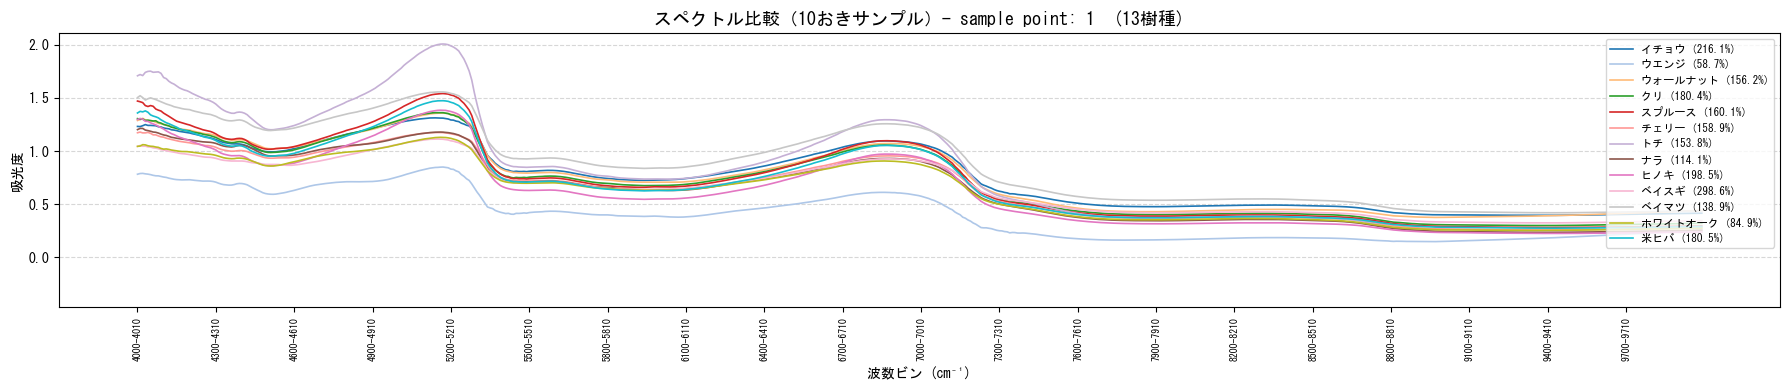

樹種,イチョウ,ウエンジ,ウォールナット,クリ,スプルース,チェリー,トチ,ナラ,ヒノキ,ベイスギ,ベイマツ,ホワイトオーク,米ヒバ
含水率,216.13,58.73,156.25,180.36,160.08,158.92,153.82,114.06,198.54,298.58,138.89,84.88,180.54


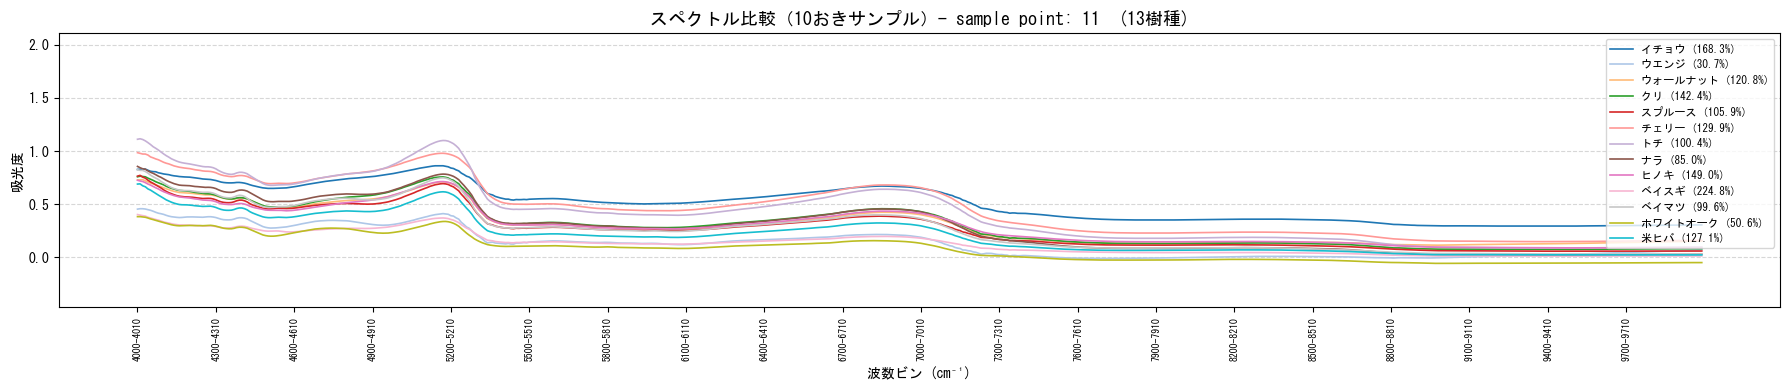

樹種,イチョウ,ウエンジ,ウォールナット,クリ,スプルース,チェリー,トチ,ナラ,ヒノキ,ベイスギ,ベイマツ,ホワイトオーク,米ヒバ
含水率,168.28,30.72,120.83,142.41,105.88,129.88,100.4,84.98,149.03,224.82,99.63,50.58,127.15


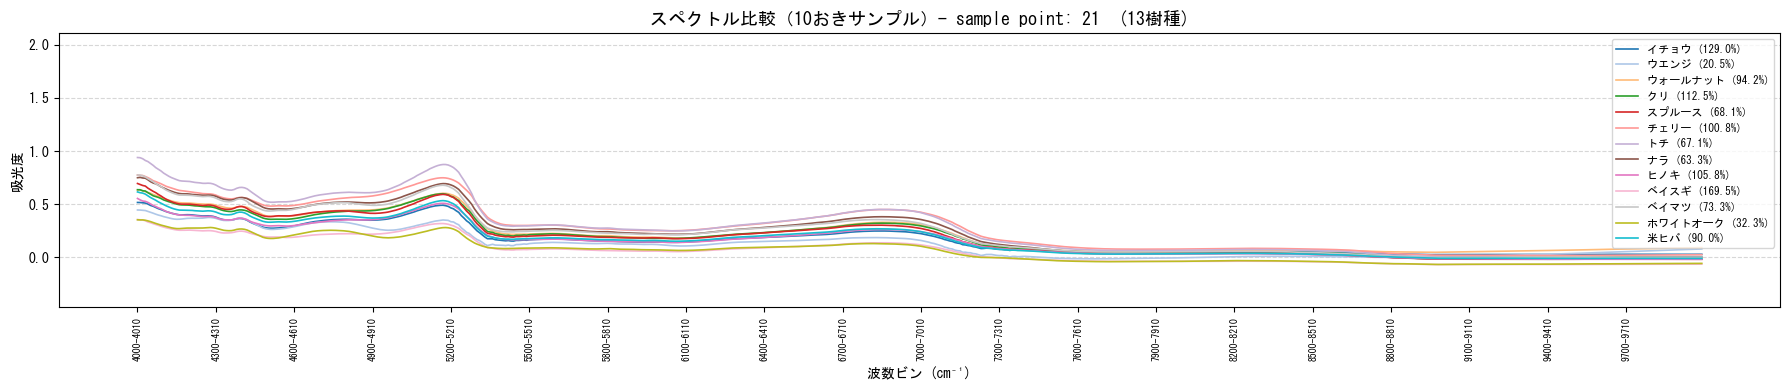

樹種,イチョウ,ウエンジ,ウォールナット,クリ,スプルース,チェリー,トチ,ナラ,ヒノキ,ベイスギ,ベイマツ,ホワイトオーク,米ヒバ
含水率,129.03,20.48,94.17,112.5,68.07,100.83,67.07,63.26,105.83,169.5,73.33,32.27,90.05


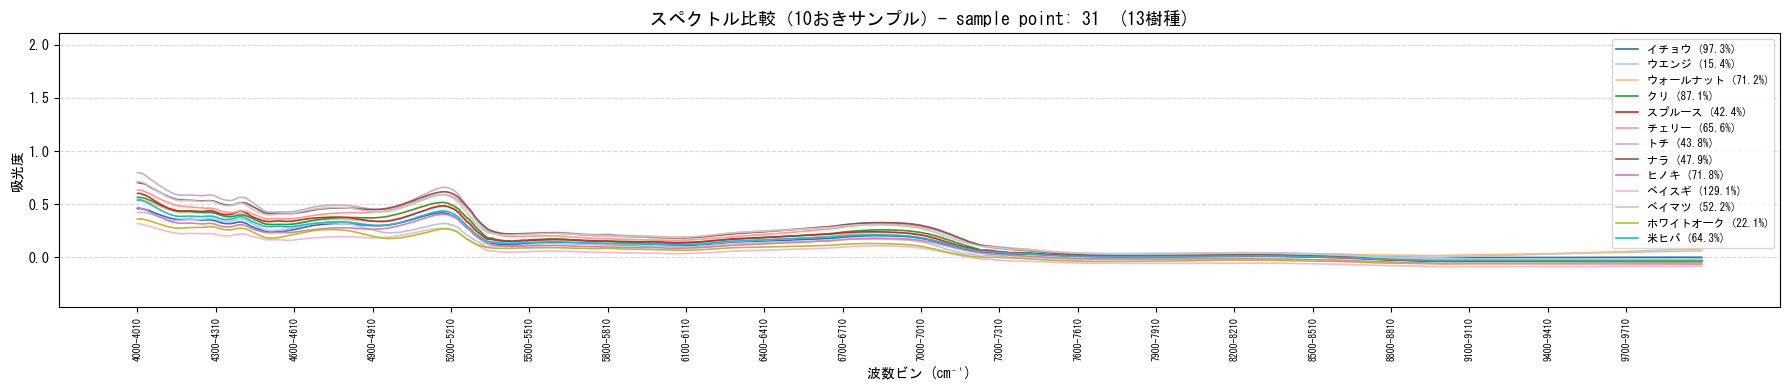

樹種,イチョウ,ウエンジ,ウォールナット,クリ,スプルース,チェリー,トチ,ナラ,ヒノキ,ベイスギ,ベイマツ,ホワイトオーク,米ヒバ
含水率,97.31,15.36,71.25,87.05,42.44,65.56,43.78,47.92,71.84,129.08,52.22,22.09,64.25


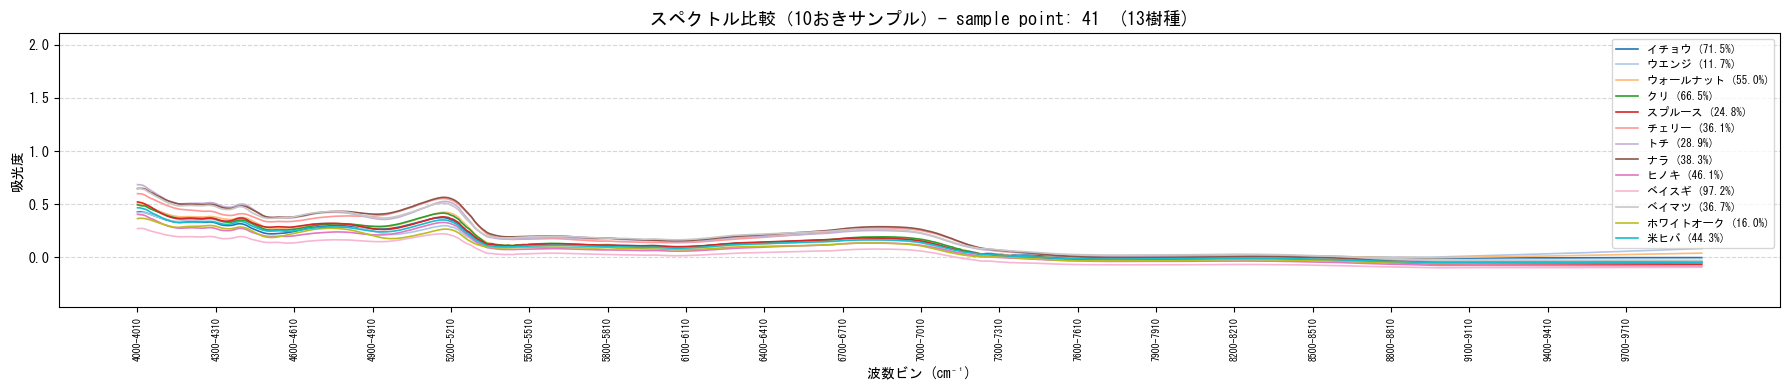

樹種,イチョウ,ウエンジ,ウォールナット,クリ,スプルース,チェリー,トチ,ナラ,ヒノキ,ベイスギ,ベイマツ,ホワイトオーク,米ヒバ
含水率,71.51,11.75,55.0,66.52,24.79,36.1,28.92,38.34,46.12,97.16,36.67,15.99,44.34


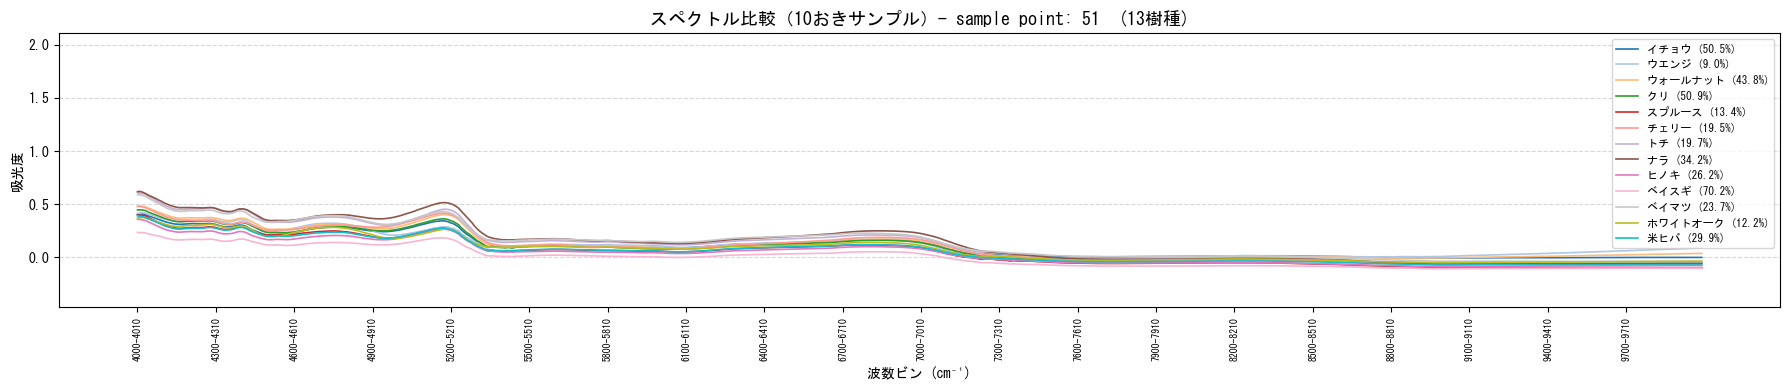

樹種,イチョウ,ウエンジ,ウォールナット,クリ,スプルース,チェリー,トチ,ナラ,ヒノキ,ベイスギ,ベイマツ,ホワイトオーク,米ヒバ
含水率,50.54,9.04,43.75,50.89,13.45,19.5,19.68,34.19,26.21,70.21,23.7,12.21,29.86


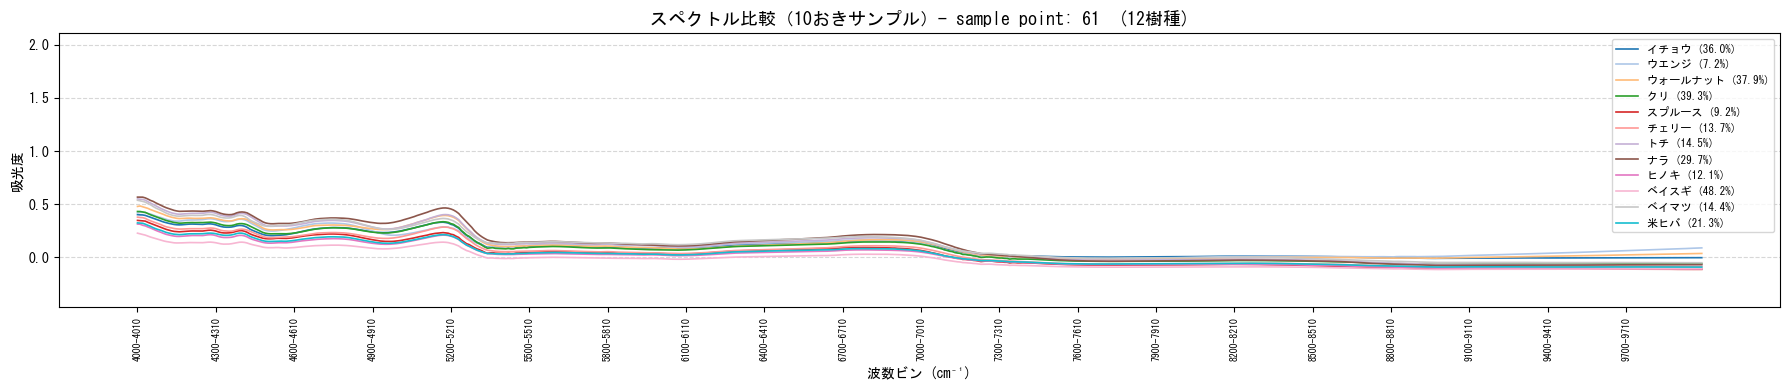

樹種,イチョウ,ウエンジ,ウォールナット,クリ,スプルース,チェリー,トチ,ナラ,ヒノキ,ベイスギ,ベイマツ,米ヒバ
含水率,36.02,7.23,37.92,39.29,9.24,13.69,14.46,29.71,12.14,48.23,14.44,21.27


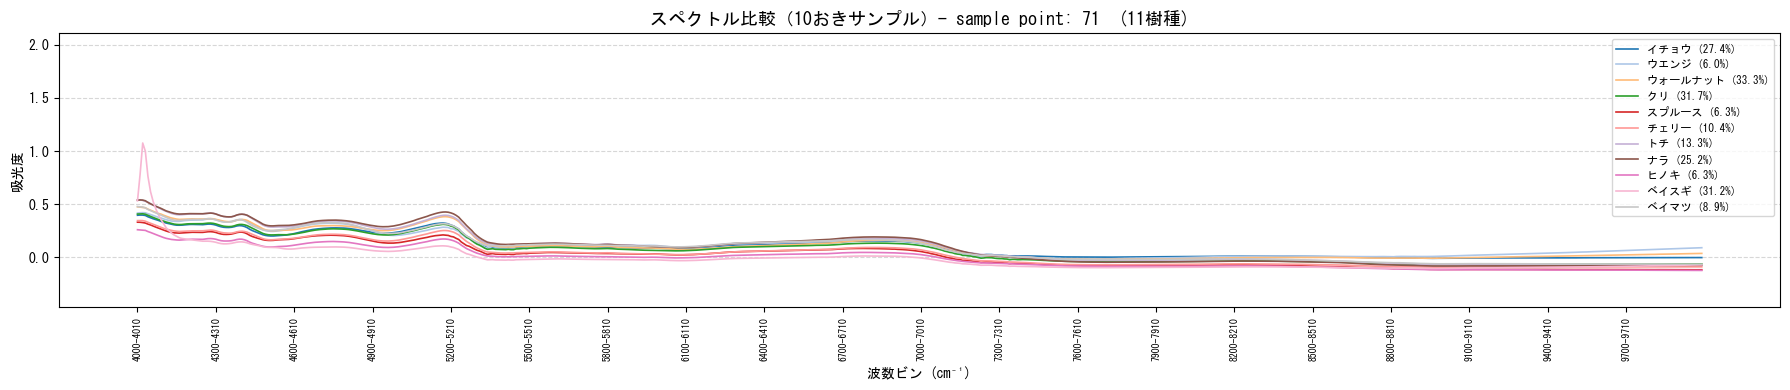

樹種,イチョウ,ウエンジ,ウォールナット,クリ,スプルース,チェリー,トチ,ナラ,ヒノキ,ベイスギ,ベイマツ
含水率,27.42,6.02,33.33,31.7,6.3,10.37,13.25,25.24,6.31,31.21,8.89


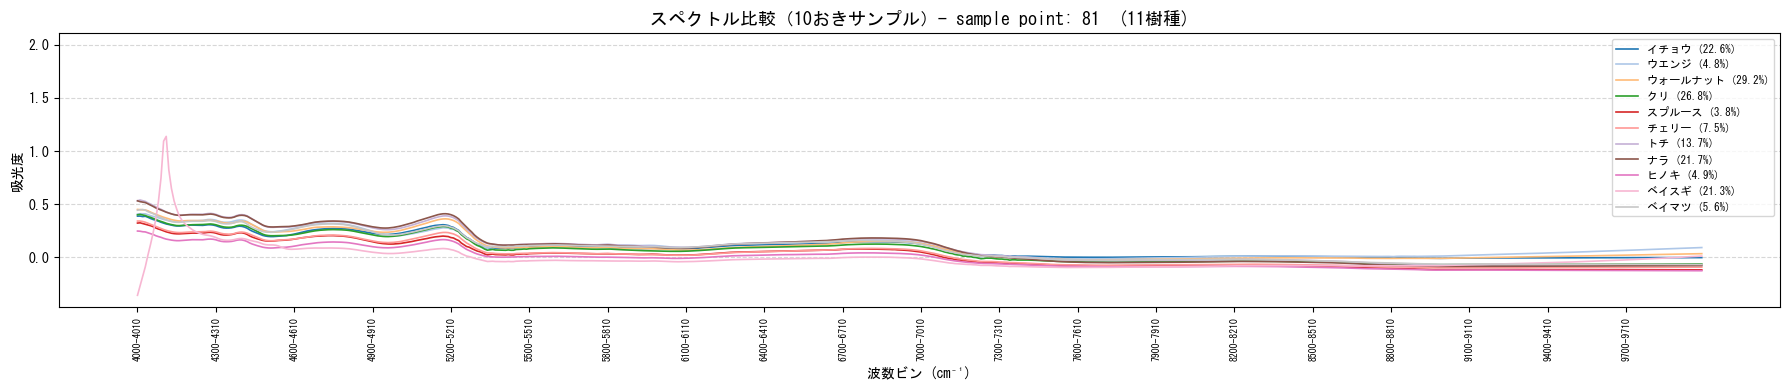

樹種,イチョウ,ウエンジ,ウォールナット,クリ,スプルース,チェリー,トチ,ナラ,ヒノキ,ベイスギ,ベイマツ
含水率,22.58,4.82,29.17,26.79,3.78,7.47,13.65,21.73,4.85,21.28,5.56


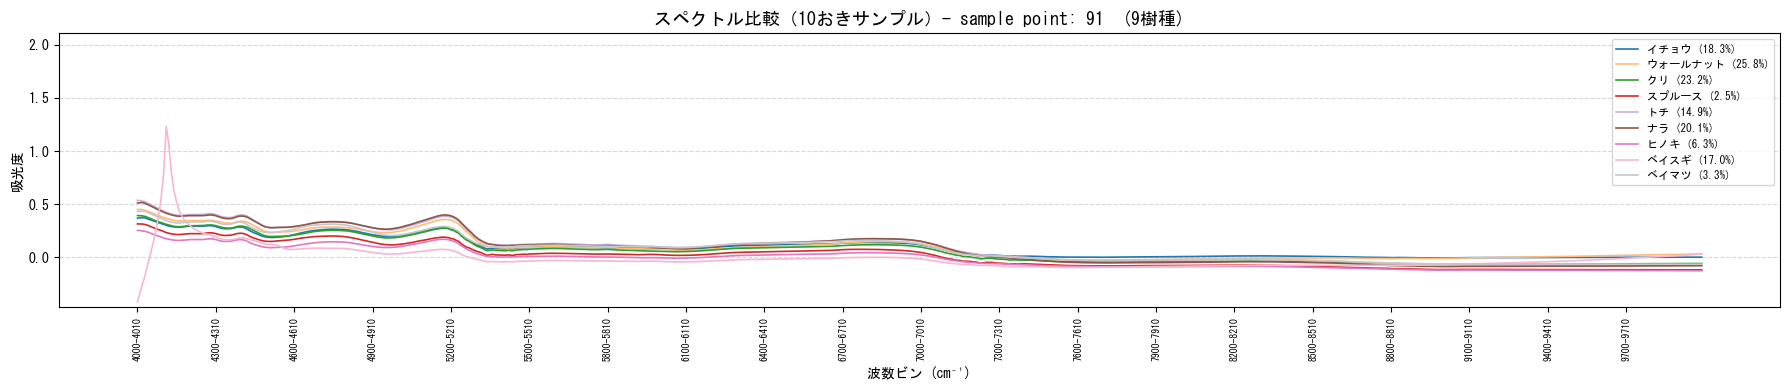

樹種,イチョウ,ウォールナット,クリ,スプルース,トチ,ナラ,ヒノキ,ベイスギ,ベイマツ
含水率,18.28,25.83,23.21,2.52,14.86,20.13,6.31,17.02,3.33


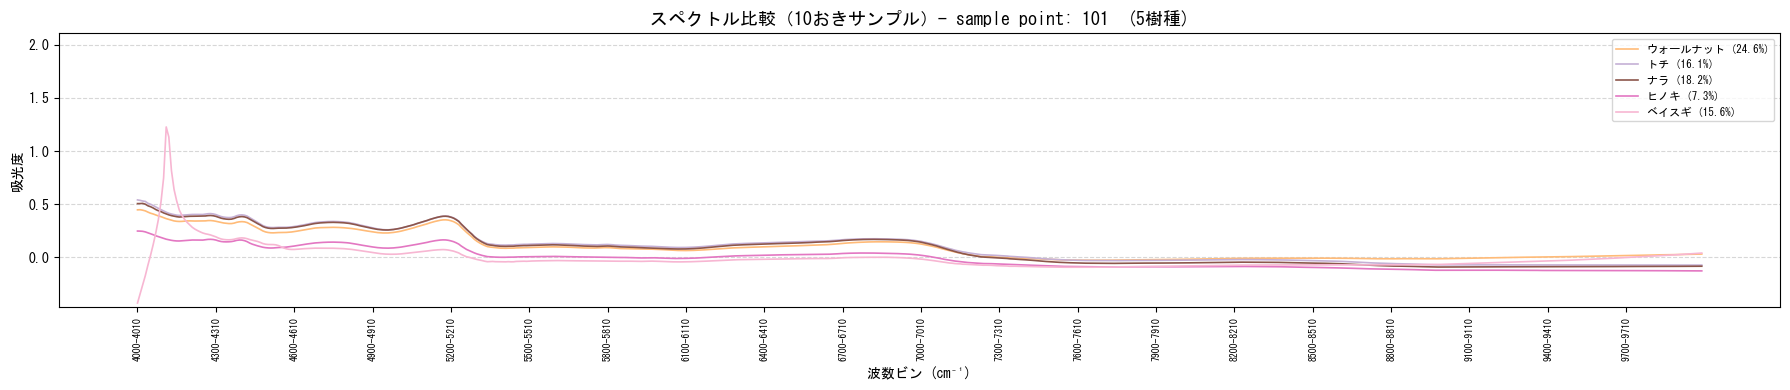

樹種,ウォールナット,トチ,ナラ,ヒノキ,ベイスギ
含水率,24.58,16.06,18.21,7.28,15.6


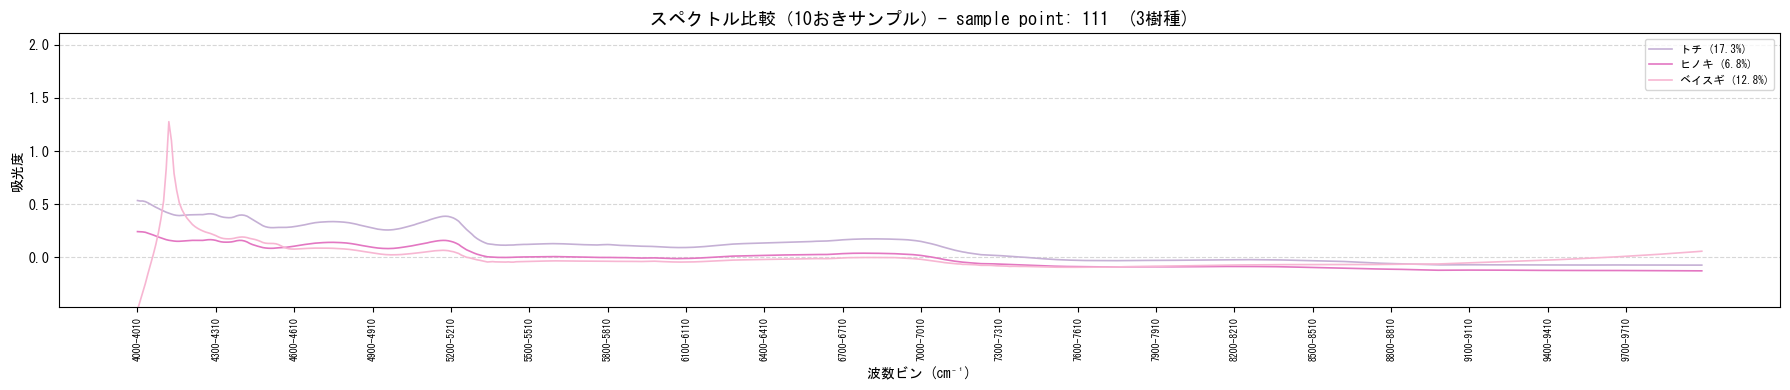

樹種,トチ,ヒノキ,ベイスギ
含水率,17.27,6.8,12.77


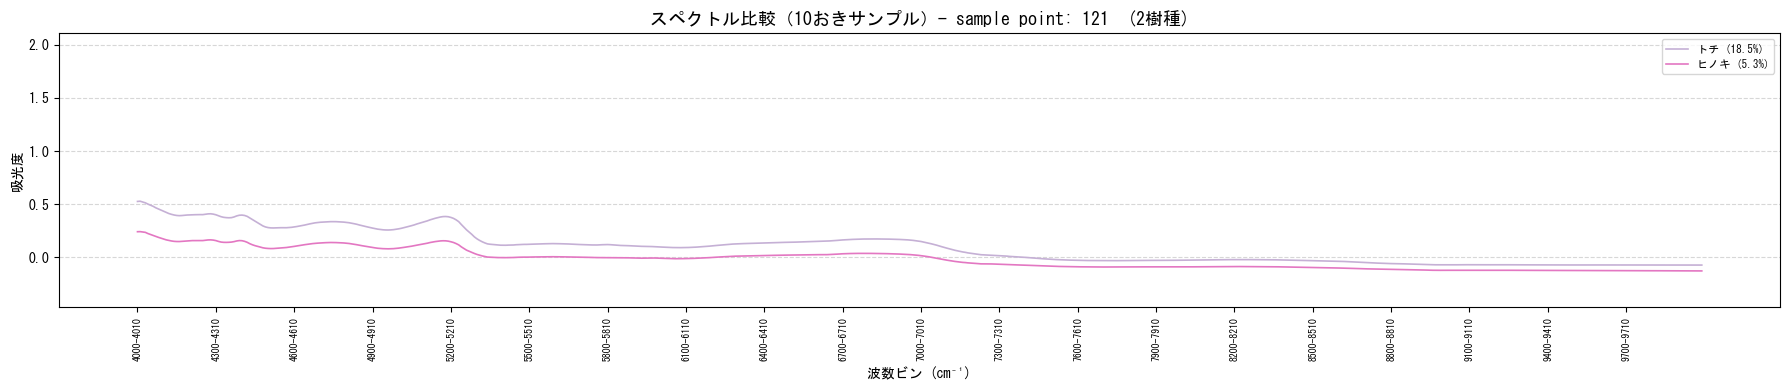

樹種,トチ,ヒノキ
含水率,18.47,5.34


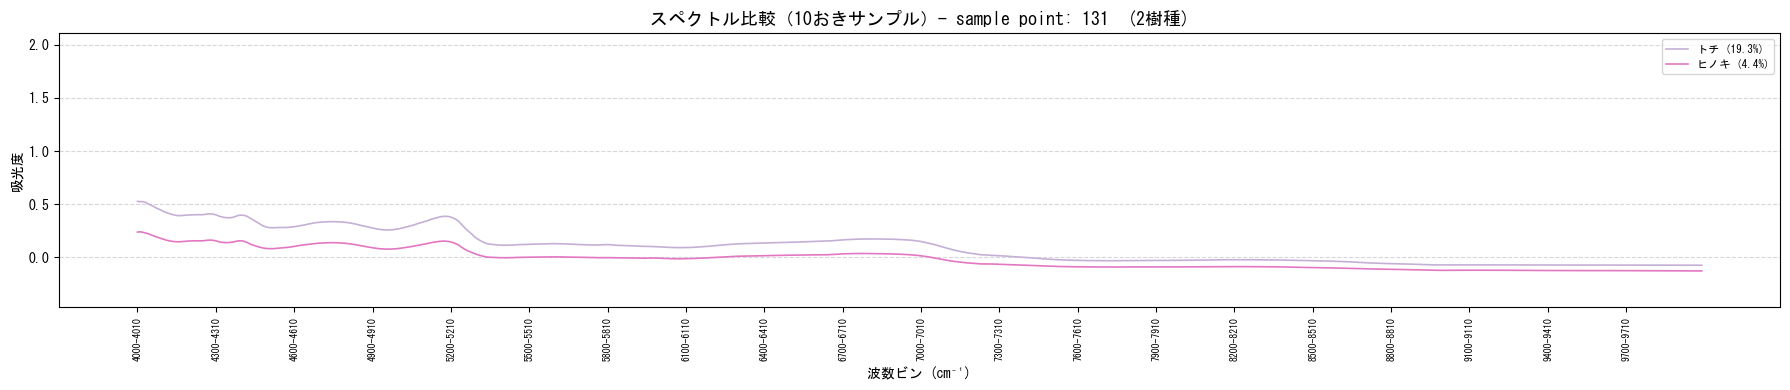

樹種,トチ,ヒノキ
含水率,19.28,4.37


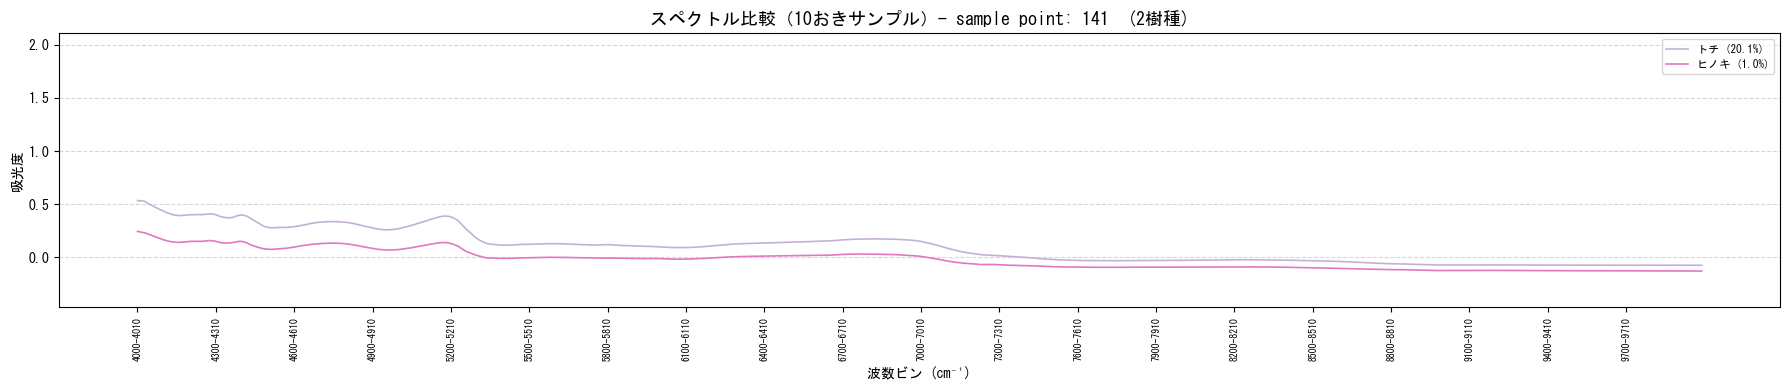

樹種,トチ,ヒノキ
含水率,20.08,0.97


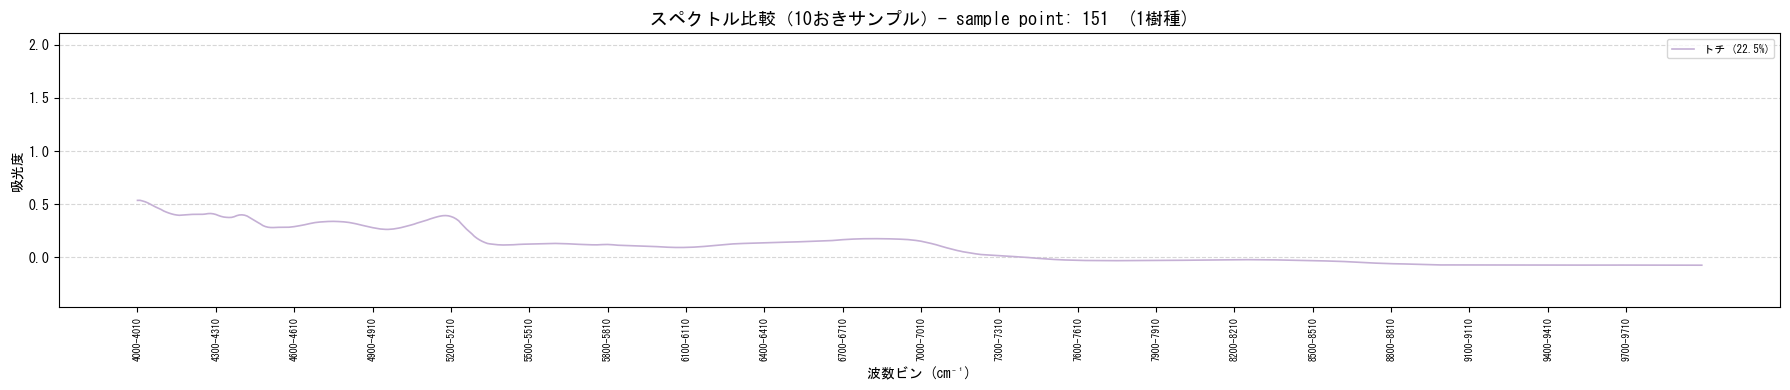

樹種,トチ
含水率,22.49


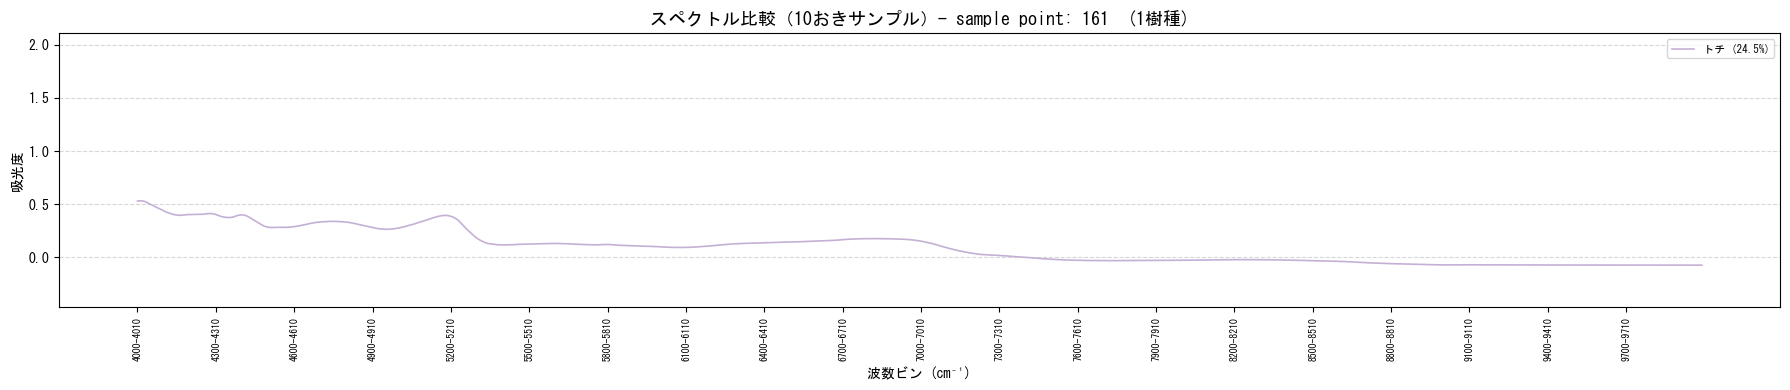

樹種,トチ
含水率,24.5


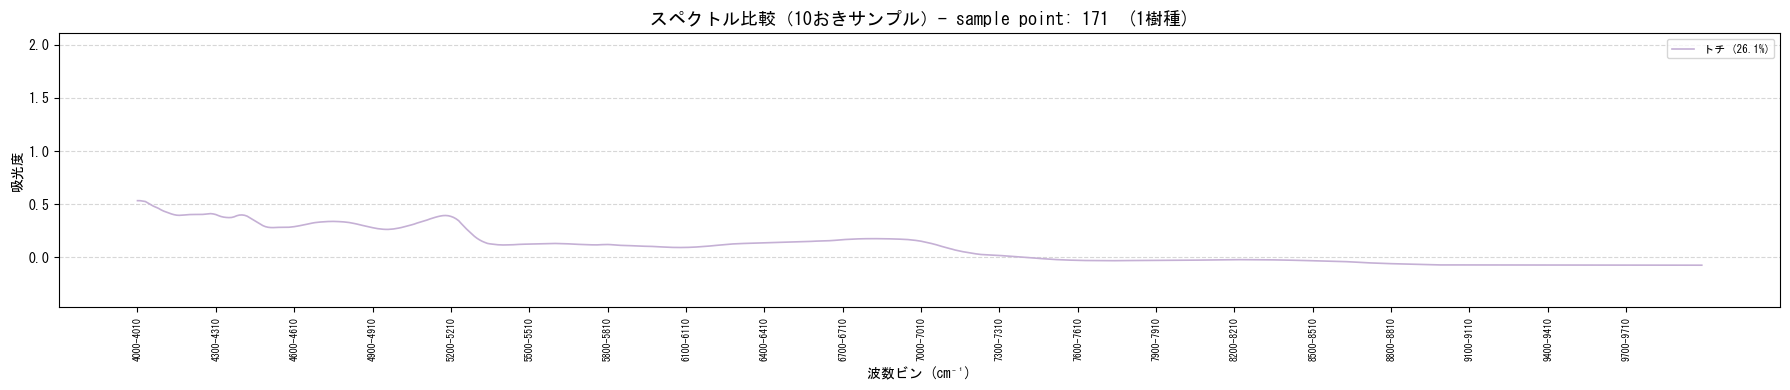

樹種,トチ
含水率,26.1


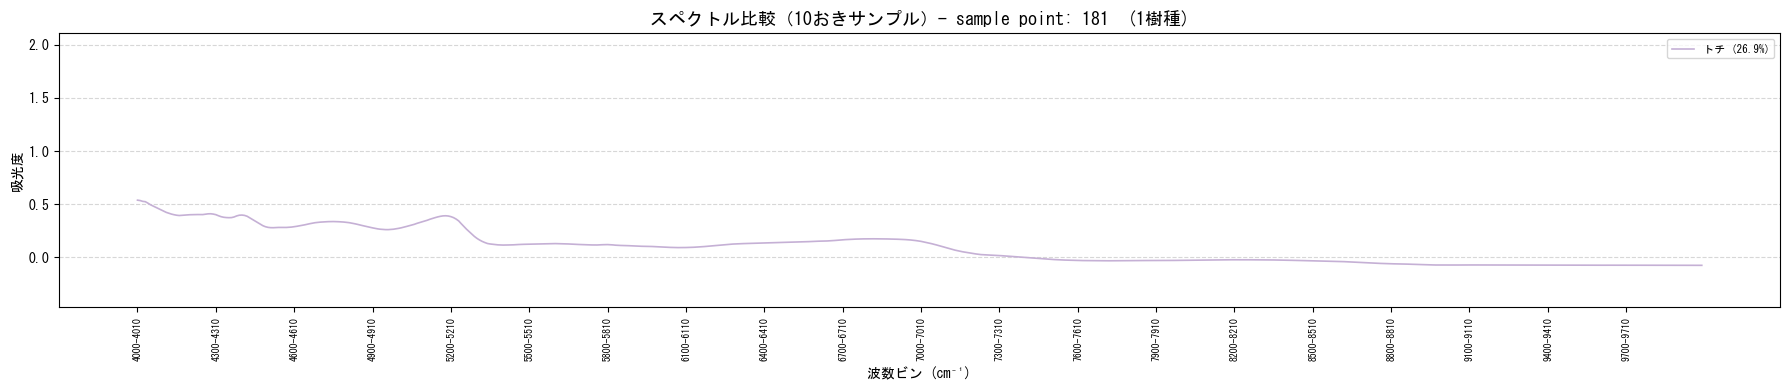

樹種,トチ
含水率,26.91


In [35]:
import numpy as np
from IPython.display import display

df_bin = pd.read_csv("../data/middle/spectrum_bin_mean.csv", encoding='utf-8-sig')

bin_cols = [c for c in df_bin.columns if c not in ['sample number', 'species number', '樹種', '含水率']]
species_list_sorted = sorted(df_bin['樹種'].unique())

# ===== パラメータ =====
sample_step = 10   # 何おきサンプル
ylim = None        # Noneで自動。手動指定例: (0, 2.0)
# ====================

if ylim is None:
    y_min = df_bin[bin_cols].min().min()
    y_max = df_bin[bin_cols].max().max()
    ylim_actual = (y_min * 0.95, y_max * 1.05)
else:
    ylim_actual = ylim

cmap = plt.get_cmap('tab20')
color_map = {sp: cmap(i / len(species_list_sorted)) for i, sp in enumerate(species_list_sorted)}

species_data = {}
for sp in species_list_sorted:
    subset = df_bin[df_bin['樹種'] == sp].sort_values('sample number').reset_index(drop=True)
    subset['point'] = subset.index + 1
    species_data[sp] = subset

max_point = max(len(v) for v in species_data.values())
x = np.arange(len(bin_cols))
tick_step = max(1, len(bin_cols) // 20)

for pt in range(1, max_point + 1, sample_step):
    fig, ax = plt.subplots(figsize=(18, 4))
    records = []
    for sp in species_list_sorted:
        row_df = species_data[sp][species_data[sp]['point'] == pt]
        if len(row_df) == 0:
            continue
        row = row_df.iloc[0]
        ax.plot(x, row[bin_cols].values, label=f"{sp} ({row['含水率']:.1f}%)", color=color_map[sp], linewidth=1.2)
        records.append({'樹種': sp, '含水率': round(row['含水率'], 2)})

    ax.set_ylim(ylim_actual)
    ax.set_ylabel('吸光度')
    ax.set_xlabel('波数ビン (cm⁻¹)')
    ax.set_xticks(x[::tick_step])
    ax.set_xticklabels(bin_cols[::tick_step], rotation=90, fontsize=7)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_title(f'スペクトル比較（{sample_step}おきサンプル）- sample point: {pt}  ({len(records)}樹種)', fontsize=13)
    plt.tight_layout()
    plt.show()

    table_df = pd.DataFrame(records).set_index('樹種').T
    display(table_df)


In [ ]:
import numpy as np
from IPython.display import display

df_bin = pd.read_csv("../data/middle/train_spectrum_bin100.csv", encoding='utf-8-sig')

bin_cols = [c for c in df_bin.columns if c not in ['sample number', 'species number', 'time', '樹種']]
species_list_sorted = sorted(df_bin['樹種'].unique())

# ===== パラメータ =====
sample_step = 10   # 何おきサンプル
ylim = (0, 2.0)    # Noneで自動。手動指定例: (0, 2.0)
# ====================

if ylim is None:
    y_min = df_bin[bin_cols].min().min()
    y_max = df_bin[bin_cols].max().max()
    ylim_actual = (y_min * 0.95, y_max * 1.05)
else:
    ylim_actual = ylim

cmap = plt.get_cmap('tab20')
color_map = {sp: cmap(i / len(species_list_sorted)) for i, sp in enumerate(species_list_sorted)}

species_data = {}
for sp in species_list_sorted:
    subset = df_bin[df_bin['樹種'] == sp].sort_values('sample number').reset_index(drop=True)
    subset['point'] = subset.index + 1
    species_data[sp] = subset

max_point = max(len(v) for v in species_data.values())
x = np.arange(len(bin_cols))
tick_step = max(1, len(bin_cols) // 20)

for pt in range(1, max_point + 1, sample_step):
    fig, ax = plt.subplots(figsize=(18, 4))
    records = []
    for sp in species_list_sorted:
        row_df = species_data[sp][species_data[sp]['point'] == pt]
        if len(row_df) == 0:
            continue
        row = row_df.iloc[0]
        ax.plot(x, row[bin_cols].values, label=sp, color=color_map[sp], linewidth=1.2)
        records.append({'樹種': sp, '含水率': round(row['含水率'], 2)})

    ax.set_ylim(ylim_actual)
    ax.set_ylabel('吸光度')
    ax.set_xlabel('波数ビン (cm⁻¹)')
    ax.set_xticks(x[::tick_step])
    ax.set_xticklabels(bin_cols[::tick_step], rotation=90, fontsize=7)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_title(f'スペクトル比較 bin100（{sample_step}おきサンプル）- sample point: {pt}  ({len(records)}樹種)', fontsize=13)
    plt.tight_layout()
    plt.show()

    table_df = pd.DataFrame(records).set_index('樹種').T
    display(table_df)


In [ ]:
import numpy as np
from IPython.display import display

df_bin = pd.read_csv("../data/middle/train_spectrum_bin100.csv", encoding='utf-8-sig')

bin_cols = [c for c in df_bin.columns if c not in ['sample number', 'species number', 'time', '樹種', '含水率']]
species_list_sorted = sorted(df_bin['樹種'].unique())

# ===== パラメータ =====
sample_step = 10   # 何おきサンプル
ylim = (0, 2.0)    # Noneで自動。手動指定例: (0, 2.0)
# ====================

if ylim is None:
    y_min = df_bin[bin_cols].min().min()
    y_max = df_bin[bin_cols].max().max()
    ylim_actual = (y_min * 0.95, y_max * 1.05)
else:
    ylim_actual = ylim

cmap = plt.get_cmap('tab20')
color_map = {sp: cmap(i / len(species_list_sorted)) for i, sp in enumerate(species_list_sorted)}

species_data = {}
for sp in species_list_sorted:
    subset = df_bin[df_bin['樹種'] == sp].sort_values('sample number').reset_index(drop=True)
    subset['point'] = subset.index + 1
    species_data[sp] = subset

# 含水率は別途取得
df_moisture = pd.read_csv("../data/middle/train_spectrum_bin100.csv", encoding='utf-8-sig')[['sample number', '樹種', '含水率']]

max_point = max(len(v) for v in species_data.values())
x = np.arange(len(bin_cols))
tick_step = max(1, len(bin_cols) // 20)

for pt in range(1, max_point + 1, sample_step):
    fig, ax = plt.subplots(figsize=(18, 4))
    records = []
    for sp in species_list_sorted:
        row_df = species_data[sp][species_data[sp]['point'] == pt]
        if len(row_df) == 0:
            continue
        row = row_df.iloc[0]
        moisture = df_moisture[df_moisture['sample number'] == row['sample number']]['含水率'].values[0]
        ax.plot(x, row[bin_cols].values, label=sp, color=color_map[sp], linewidth=1.2)
        records.append({'樹種': sp, '含水率': round(moisture, 2)})

    ax.set_ylim(ylim_actual)
    ax.set_ylabel('吸光度')
    ax.set_xlabel('波数ビン (cm⁻¹)')
    ax.set_xticks(x[::tick_step])
    ax.set_xticklabels(bin_cols[::tick_step], rotation=90, fontsize=7)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_title(f'スペクトル比較 bin100 含水率除外（{sample_step}おきサンプル）- sample point: {pt}  ({len(records)}樹種)', fontsize=13)
    plt.tight_layout()
    plt.show()

    table_df = pd.DataFrame(records).set_index('樹種').T
    display(table_df)


In [ ]:
import numpy as np
from IPython.display import display

df_bin = pd.read_csv("../data/middle/train_spectrum_bin1000.csv", encoding='utf-8-sig')

bin_cols = [c for c in df_bin.columns if c not in ['sample number', 'species number', 'time', '樹種', '含水率']]
species_list_sorted = sorted(df_bin['樹種'].unique())

# ===== パラメータ =====
sample_step = 10   # 何おきサンプル
ylim = (0, 2.0)    # Noneで自動。手動指定例: (0, 2.0)
# ====================

if ylim is None:
    y_min = df_bin[bin_cols].min().min()
    y_max = df_bin[bin_cols].max().max()
    ylim_actual = (y_min * 0.95, y_max * 1.05)
else:
    ylim_actual = ylim

cmap = plt.get_cmap('tab20')
color_map = {sp: cmap(i / len(species_list_sorted)) for i, sp in enumerate(species_list_sorted)}

species_data = {}
for sp in species_list_sorted:
    subset = df_bin[df_bin['樹種'] == sp].sort_values('sample number').reset_index(drop=True)
    subset['point'] = subset.index + 1
    species_data[sp] = subset

max_point = max(len(v) for v in species_data.values())
x = np.arange(len(bin_cols))
tick_step = max(1, len(bin_cols) // 20)

for pt in range(1, max_point + 1, sample_step):
    fig, ax = plt.subplots(figsize=(18, 4))
    records = []
    for sp in species_list_sorted:
        row_df = species_data[sp][species_data[sp]['point'] == pt]
        if len(row_df) == 0:
            continue
        row = row_df.iloc[0]
        ax.plot(x, row[bin_cols].values, label=sp, color=color_map[sp], linewidth=1.2)
        records.append({'樹種': sp, '含水率': round(row['含水率'], 2)})

    ax.set_ylim(ylim_actual)
    ax.set_ylabel('吸光度')
    ax.set_xlabel('波数ビン (cm⁻¹)')
    ax.set_xticks(x[::tick_step])
    ax.set_xticklabels(bin_cols[::tick_step], rotation=90, fontsize=7)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_title(f'スペクトル比較 bin1000（{sample_step}おきサンプル）- sample point: {pt}  ({len(records)}樹種)', fontsize=13)
    plt.tight_layout()
    plt.show()

    table_df = pd.DataFrame(records).set_index('樹種').T
    display(table_df)


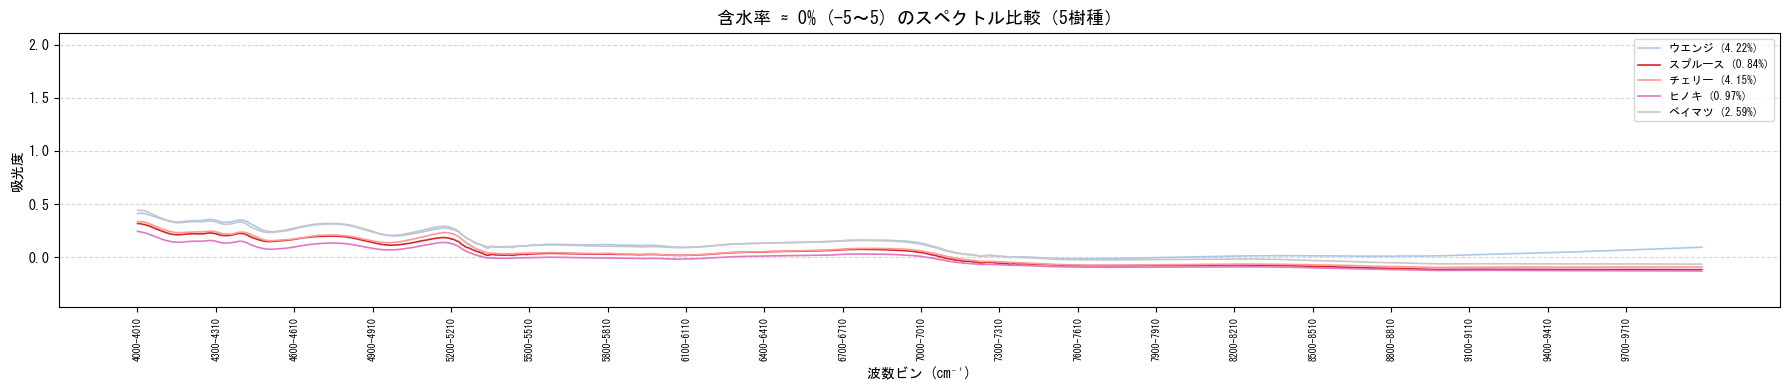

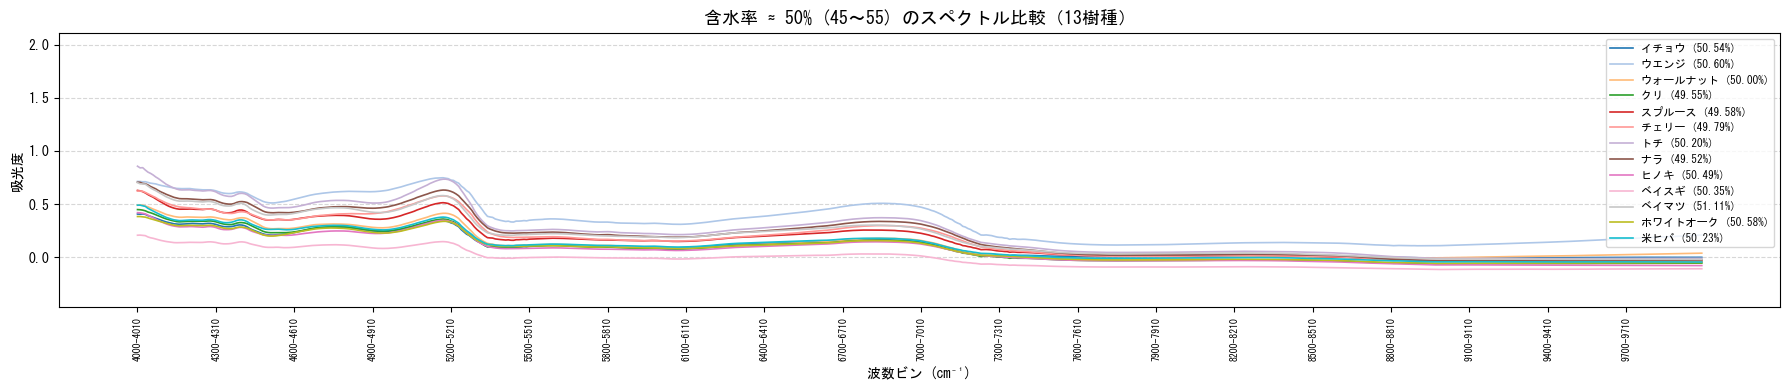

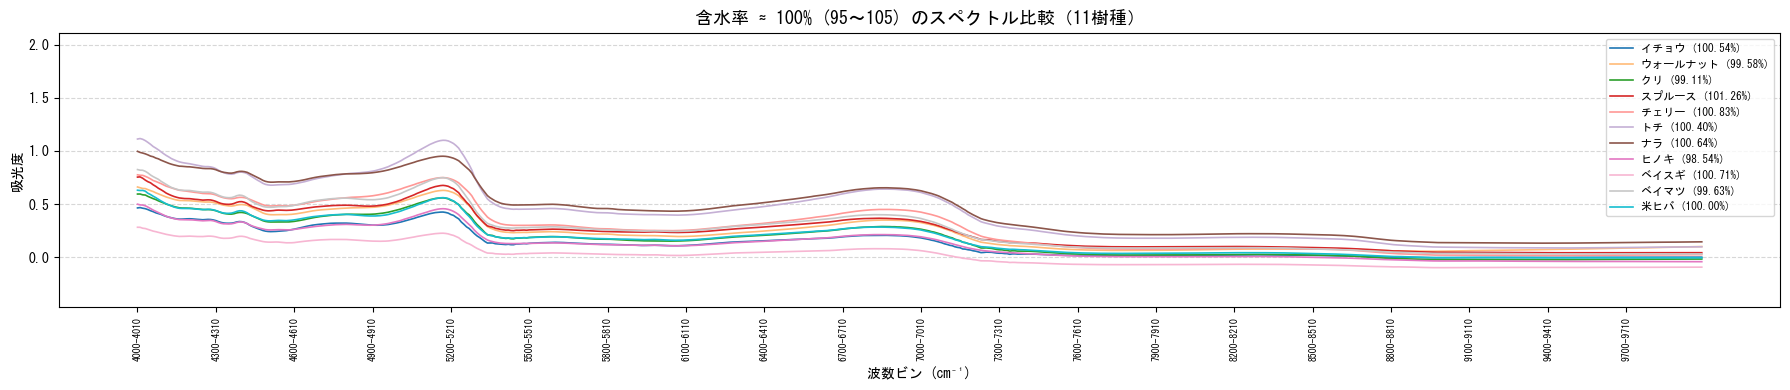

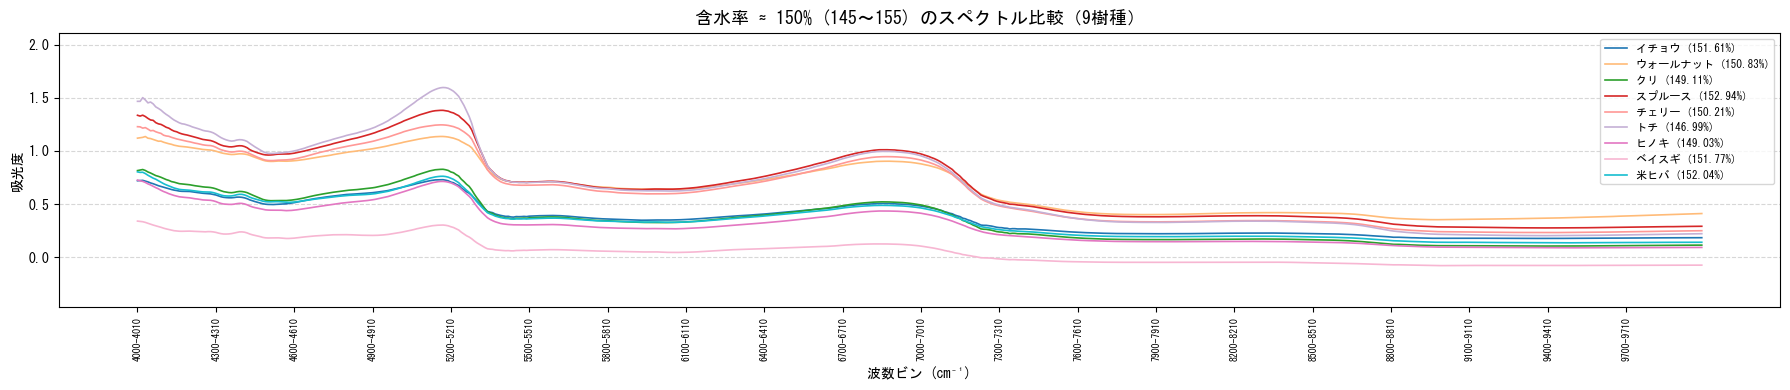

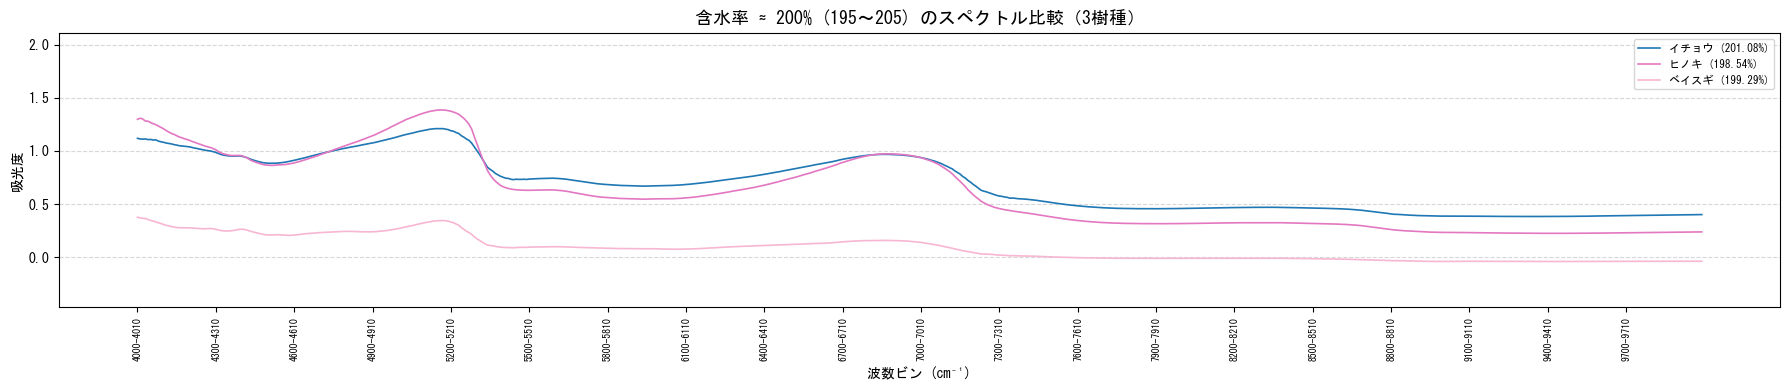

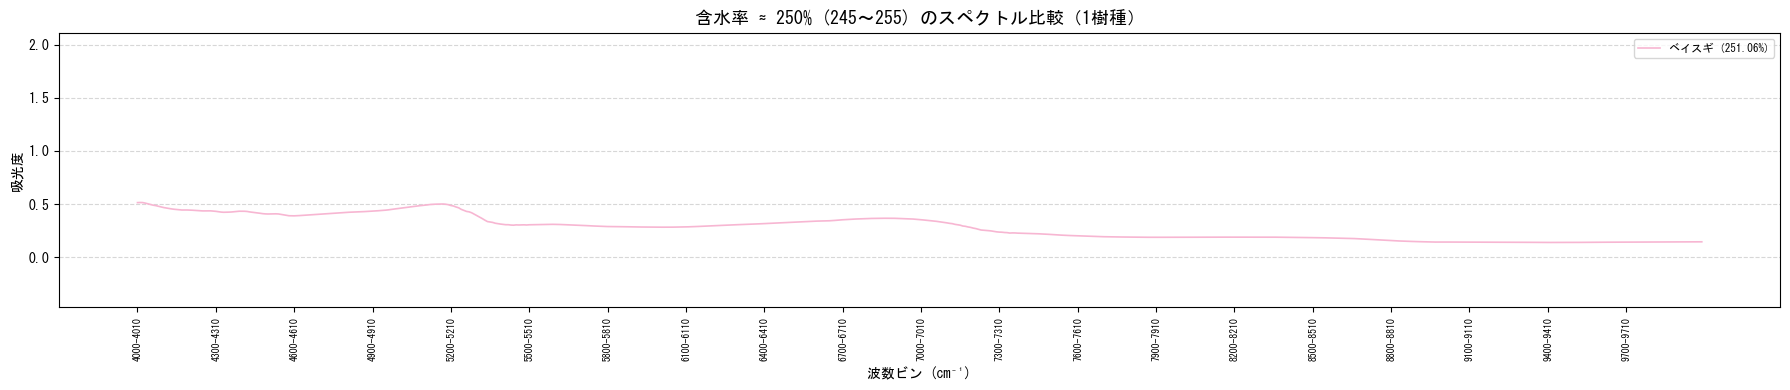

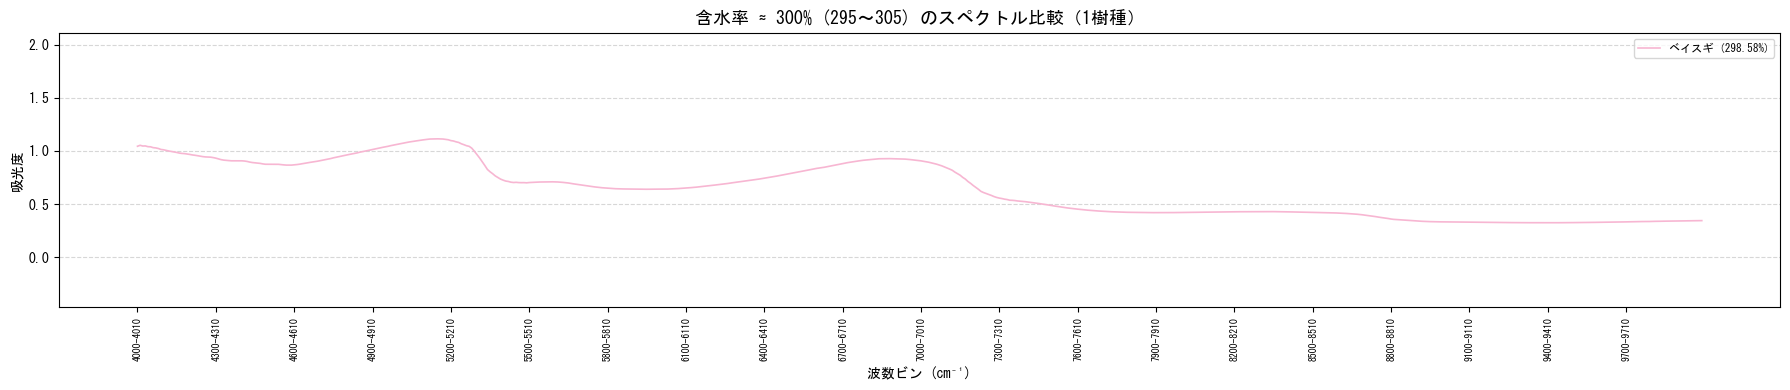

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'MS Gothic'

# ===== パラメータ =====
moisture_levels = list(range(0, 301, 50))  # 0, 50, 100, ..., 300
half_width = 5    # 各レベル ± half_width の範囲を検索 (例: 200 → 195〜205)
ylim = None       # Noneで自動。手動指定例: (0, 2.0)
# ====================

df_bin = pd.read_csv("../data/middle/spectrum_bin_mean.csv", encoding='utf-8-sig')
bin_cols = [c for c in df_bin.columns if c not in ['sample number', 'species number', '樹種', '含水率']]
species_list_sorted = sorted(df_bin['樹種'].unique())

cmap = plt.get_cmap('tab20')
color_map = {sp: cmap(i / len(species_list_sorted)) for i, sp in enumerate(species_list_sorted)}

if ylim is None:
    y_min = df_bin[bin_cols].min().min()
    y_max = df_bin[bin_cols].max().max()
    ylim_actual = (y_min * 0.95, y_max * 1.05)
else:
    ylim_actual = ylim

x = np.arange(len(bin_cols))

for level in moisture_levels:
    low, high = level - half_width, level + half_width
    # 各樹種について [low, high] の中で最もlevelに近いレコードを1件取得
    records = []
    for species in species_list_sorted:
        subset = df_bin[
            (df_bin['樹種'] == species) &
            (df_bin['含水率'] >= low) &
            (df_bin['含水率'] <= high)
        ]
        if len(subset) == 0:
            continue
        row = subset.loc[(subset['含水率'] - level).abs().idxmin()]
        records.append({'樹種': species, '含水率': row['含水率'], 'spectrum': row[bin_cols].values})



    fig, ax = plt.subplots(figsize=(18, 4))
    for rec in records:
        ax.plot(x, rec['spectrum'], label=f"{rec['樹種']} ({rec['含水率']:.2f}%)", color=color_map[rec['樹種']], linewidth=1.2)

    ax.set_ylim(ylim_actual)
    ax.set_ylabel('吸光度')
    ax.set_xlabel('波数ビン (cm⁻¹)')
    tick_step = max(1, len(bin_cols) // 20)
    ax.set_xticks(x[::tick_step])
    ax.set_xticklabels(bin_cols[::tick_step], rotation=90, fontsize=7)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_title(f'含水率 ≈ {level}% ({low}〜{high}) のスペクトル比較（{len(records)}樹種）', fontsize=13)
    plt.tight_layout()
    plt.show()
